<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<center>
    <b>
        <h3>Machine Learning and Deep Learning Fundamentals and Applications - 2501CS633</h3>
        <h3>Lab - 4</h3>
        <h3>Rathod Harmik Kamleshbhai - 24010101680</h3>
    </b>
</center>

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


## Step 2. Import the dataset

In [2]:
df = pd.read_csv('50_Startups.csv')

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [4]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [5]:
Y = df['Profit']
X = df.drop('Profit', axis=1)
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [6]:
X1 = pd.get_dummies(X, columns=['State'], drop_first=True)

In [7]:
X1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [8]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X1, Y, test_size=0.2, random_state=724)

## Step 8  Import LinearRegression model from linear_model family 

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## Step 9  Fit the data

In [11]:
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 10  Predict the data

In [12]:
Y_pred = model.predict(X_test)  

## Step 11  Display Result

In [13]:
# y_test and y_predict
Y_pred

array([130807.56931253, 152063.01279219,  46055.8893643 ,  69353.77784015,
       115213.91245284, 111845.62891365, 133710.45252117,  87095.166071  ,
       188848.69534377, 192307.44557744])

In [14]:
import matplotlib.pyplot as plt

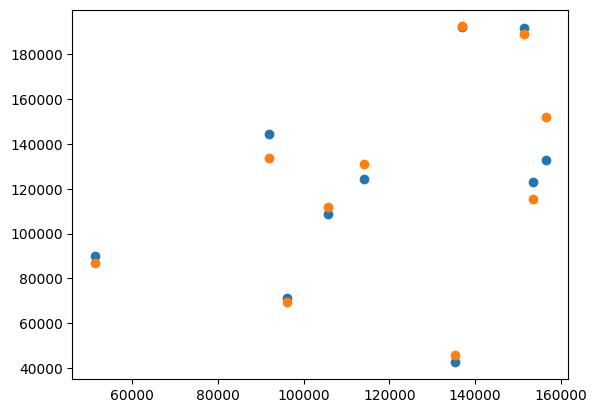

In [15]:
plt.scatter(X_test["Administration"], Y_test)
plt.scatter(X_test["Administration"], Y_pred)

## RSS

In [16]:
import numpy as np

In [17]:
np.sum( (Y_test.values - Y_pred)**2 )

633280404.3175461

In [18]:
len(Y_pred)

10

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
mean_squared_error(Y_test, Y_pred)

63328040.43175461

## R Square

In [21]:
from sklearn.metrics import r2_score

In [22]:
r2_score(Y_test, Y_pred)

0.9690866340976173

## Now use Polynomial Regression on Position_Salaries dataset

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
df = pd.read_csv('Position_Salaries.csv')

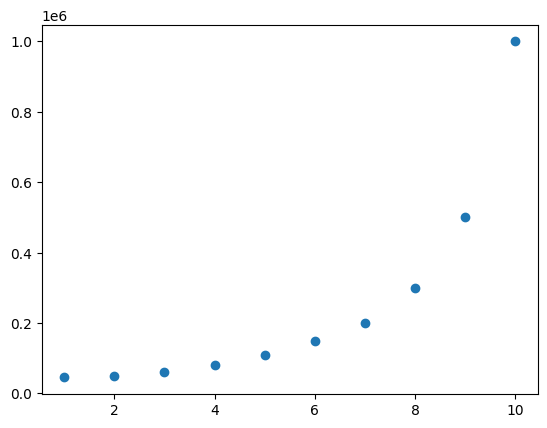

In [25]:
plt.scatter(df.Level, df.Salary)

In [26]:
Y = df['Salary']
X = df['Level']
X

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Level, dtype: int64

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=7)

In [28]:
X_train

2     3
1     2
9    10
7     8
3     4
6     7
4     5
Name: Level, dtype: int64

In [29]:
X1 = PolynomialFeatures(degree=2).fit_transform(X_train.values.reshape(-1,1))

In [30]:
model = LinearRegression()

In [31]:
model.fit(X1, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
Y_pred = model.predict(PolynomialFeatures(degree=2).fit_transform(X_test.values.reshape(-1,1)))

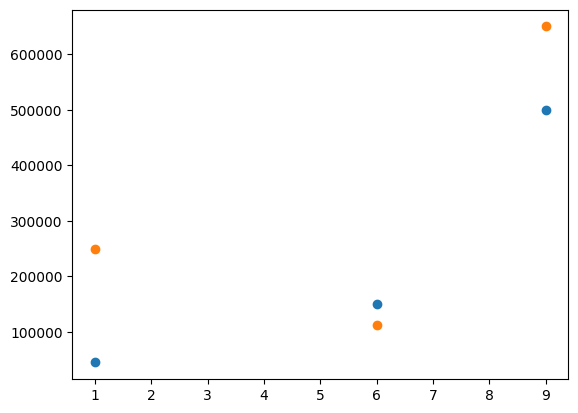

In [40]:
plt.scatter(X_test, Y_test)
plt.scatter(X_test, Y_pred)